# Assignment 03 - Logistic Regression

**Topics Covered:**
- Logistic Regression
- Regularization
- Cross Validation & Hyperparameter Tuning

**Datasets:**
- Fashion MNIST (from `openml.datasets`)
- Bank Dataset (from csv file attached)

**Student Name:** Raghad Abdelhameed
---

**Instructions:**
- Complete the code where you're asked to. **Do not modify or remove any other code**.
- Answer all written questions in the Markdown cells


In [2]:
%matplotlib notebook
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


np.random.seed(0)

In [3]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Part 1
Run the following cells to download fmnist dataset which will be used for the rest of the assignment.

In [4]:
!pip install openml

# General imports
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import openml as oml
from matplotlib import cm


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.4/160.4 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.8/93.8 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 43.3 MB/s eta 0:00:00
  Created wheel for liac-arff: filename=liac_arff-2.5.0-py3-none-any.whl size=11717 sha256=81426489ae6a4889e8506276cd0d5e84084d27b622cf4db002afbfe0009f36fd
  Stored in directory: /root/.cache/pip/wheels/a9/ac/cf/c2919807a5c623926d217c0a18eb5b457e5c19d242c3b5963a
Successfully built liac-arff


In [5]:
# Download FMINST data. Takes a while the first time.
fmnist = oml.datasets.get_dataset(40996)
X, y, _, _ = fmnist.get_data(target=fmnist.default_target_attribute);
fmnist_classes = {0:"T-shirt/top", 1: "Trouser", 2: "Pullover", 3: "Dress", 4: "Coat", 5: "Sandal",
                  6: "Shirt", 7: "Sneaker", 8: "Bag", 9: "Ankle boot"}

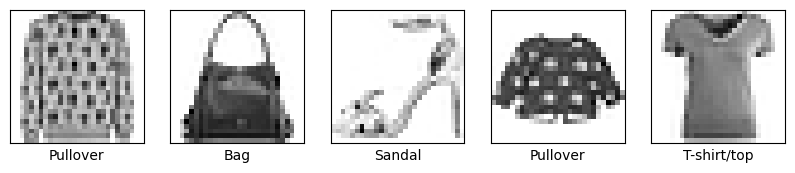

In [8]:
# Take some random examples, reshape to a 32x32 image and plot
from random import randint
fig, axes = plt.subplots(1, 5,  figsize=(10, 5))
for i in range(5):
    n = randint(0,70000)
    axes[i].imshow(X.values[n].reshape(28, 28), cmap=plt.cm.gray_r)
    axes[i].set_xlabel((fmnist_classes[int(y.values[n])]))
    axes[i].set_xticks(()), axes[i].set_yticks(())
plt.show();

### Question 1
First, we'll try the default Logistic Regression and Decision tree as a point of reference. To see whether our models are overfitting, we also evaluate the training set error. This can be done using cross_validation.

Implement the following `evaluate_learners` function which evaluates each classifier passed into it on the given data, and then returns both the train and test scores of each as a list. You must use `cross_validate` function.

In [9]:
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Take a 10% stratified subsample to speed up experimentation
Xs, _, ys, _ = train_test_split(X,y, stratify=y, train_size=0.1, random_state =0)

In [10]:
def evaluate_learners(classifiers, X, y):
    """ Evaluate each classifier in 'classifiers' with cross-validation on the provided (X, y) data.

    Given a list of scikit-learn classifiers [Classifier1, Classifier2, ..., ClassifierN] return two lists:
     - a list with the scores obtained on the training samples for each classifier,
     - a list with the test scores obtained on the test samples for each classifier.
     The order of scores should match the order in which the classifiers were originally provided. E.g.:
     [Classifier1 train score, ..., ClassifierN train score], [Classifier1 test score, ..., ClassifierN test score]
    """
    train_scores = []
    test_scores = []

    for clf in classifiers:
        cv_results = cross_validate(clf, X, y, cv=5, return_train_score=True)
        train_scores.append(cv_results['train_score'])
        test_scores.append(cv_results['test_score'])

    return train_scores, test_scores

With this small sample of our data we can now train and evaluate the two classifiers.

In [11]:
classifiers = [LogisticRegression(), DecisionTreeClassifier()]
train_scores, test_scores = evaluate_learners(classifiers, Xs, ys)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Print train scores and test scores.

In [12]:
# print scores
# print scores
print("Logistic Regression - Train scores:", train_scores[0])
print("Logistic Regression - Test scores:", test_scores[0])
print("\nDecision Tree - Train scores:", train_scores[1])
print("Decision Tree - Test scores:", test_scores[1])

Logistic Regression - Train scores: [0.9125     0.92053571 0.92125    0.92089286 0.91767857]
Logistic Regression - Test scores: [0.835      0.80071429 0.82       0.81428571 0.81214286]

Decision Tree - Train scores: [1. 1. 1. 1. 1.]
Decision Tree - Test scores: [0.74214286 0.73214286 0.73285714 0.74785714 0.74214286]


### Regularization
We will now tune these algorithm's regularization hyperparameters: C (Inverse of regularization strength) in logistic regression (smaller values specify stronger regularization), and the maximum depth (max_depth) in decision tree. C should be varied on a log scale (i.e. [0.01, 0.1, 1, 10, 100]) and max_depth should be varied uniformly (i.e. [1,2,3,4]).

### Question 2
In the following cells we vary the regularization parameters in the range given above and, for each classifier, we create a line plot that plots both the training and test score for every value of the regularization hyperparameter. Hence, 2 plots are produced, one for each classifier. We use 5-fold cross validation for all scores, but only plot the means.


In [13]:
from sklearn.model_selection import GridSearchCV

param_c = {'C': np.logspace(-12, 12, num=22)}
param_d = {'max_depth': np.arange(1, 11, 1)}
grids = [param_c, param_d]
grid_searches = [GridSearchCV(clf, grid, n_jobs=-1, cv=3, return_train_score=True).fit(Xs, ys) for clf, grid in zip(classifiers, grids)]

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [14]:
# Generic plot for 1D grid search
# grid_search: the result of the GridSearchCV
# param_name: the name of the parameter that is being varied
def plot_tuning(grid_search, param_name, ax, log):
    ax.plot(grid_search.param_grid[param_name], grid_search.cv_results_['mean_test_score'], marker = '.', label = 'Test score')
    ax.plot(grid_search.param_grid[param_name], grid_search.cv_results_['mean_train_score'], marker = '.', label = 'Train score')
    ax.set_ylabel('score (ACC)')
    ax.set_xlabel(param_name)
    ax.legend()
    if log:
        ax.set_xscale('log')
    ax.set_title(grid_search.best_estimator_.__class__.__name__)
    bp, bs = grid_search.best_params_[param_name], grid_search.best_score_
    ax.text(bp,bs,"  C:{:.2E}, ACC:{:.4f}".format(bp,bs))

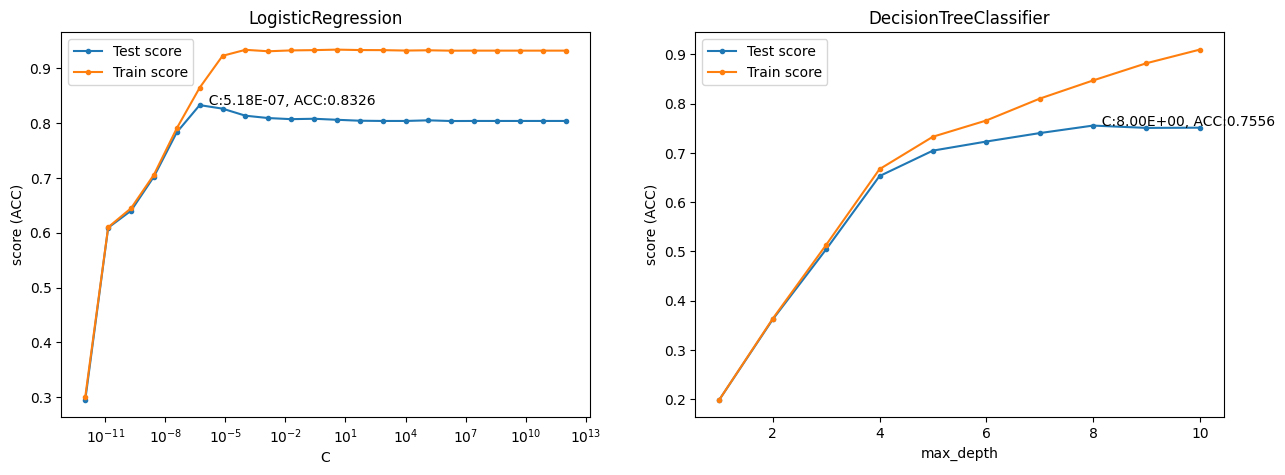

In [15]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15,5))
for grid_search, param, ax in zip(grid_searches,['C','max_depth'],axes):
    if param == 'C':
        log = True
    else:
        log = False
    plot_tuning(grid_search, param, ax, log=log)

Interpret the plots. When are the methods underfitting? When are they overfitting? How sensitive are they to the regularization hyperparameter?

**Answer**
Logistic Regression (C parameter):

Underfitting (small C values, strong regularization): When C is very small (e.g., 1e-12 to 1e-8), both training and test scores are low. The model is too constrained and cannot capture patterns in the data.

Overfitting (large C values, weak regularization): When C is very large (e.g., 1e+8 to 1e+12), the training score remains high but test score starts to decrease slightly, indicating overfitting.

Sensitivity: Logistic regression is relatively robust to C values across a wide range (from about 1e-4 to 1e+4). The performance plateaus, showing that the model is not extremely sensitive to regularization strength within this range.

**Answer**
Decision Tree (max_depth parameter):

Underfitting (small max_depth values, e.g., 1-2): Both training and test scores are low. The tree is too shallow to capture the complexity of the data.

Overfitting (large max_depth values, e.g., >5): Training score reaches near 1.0, but test score plateaus and may even decrease slightly. The tree memorizes the training data.

Sensitivity: Decision trees are more sensitive to max_depth. There's a clear optimal range (around depth 4-6) where test performance is best.

## Interpreting misclassifications
We train a logistic regression model on the data to look at the confusion matrix

In [16]:
# Create a stratified train-test split on a sample
X_train, X_test, y_train, y_test = train_test_split(Xs,ys, stratify=ys, random_state=0)

In [17]:
# model implementation:
model = LogisticRegression(C=1e-7).fit(X_train,y_train)
y_pred = model.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Question 3
Draw the complete confusion matrix for the true and predicted test data. Interpret the results.

In [18]:
from sklearn.metrics import confusion_matrix

#### Code for calculating the confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[147   2   2  12   0   0   9   0   3   0]
 [  0 169   4   2   0   0   0   0   0   0]
 [  2   0 119   1  32   0  18   0   3   0]
 [  8   0   1 155   5   0   6   0   0   0]
 [  0   0  16  10 135   0  14   0   0   0]
 [  0   0   0   0   0 122   0  34   1  18]
 [ 51   1  19   8  20   0  72   0   4   0]
 [  0   0   0   0   0   3   0 157   1  14]
 [  0   0   3   4   0   1   1   0 166   0]
 [  0   0   0   0   0   1   0  10   0 164]]


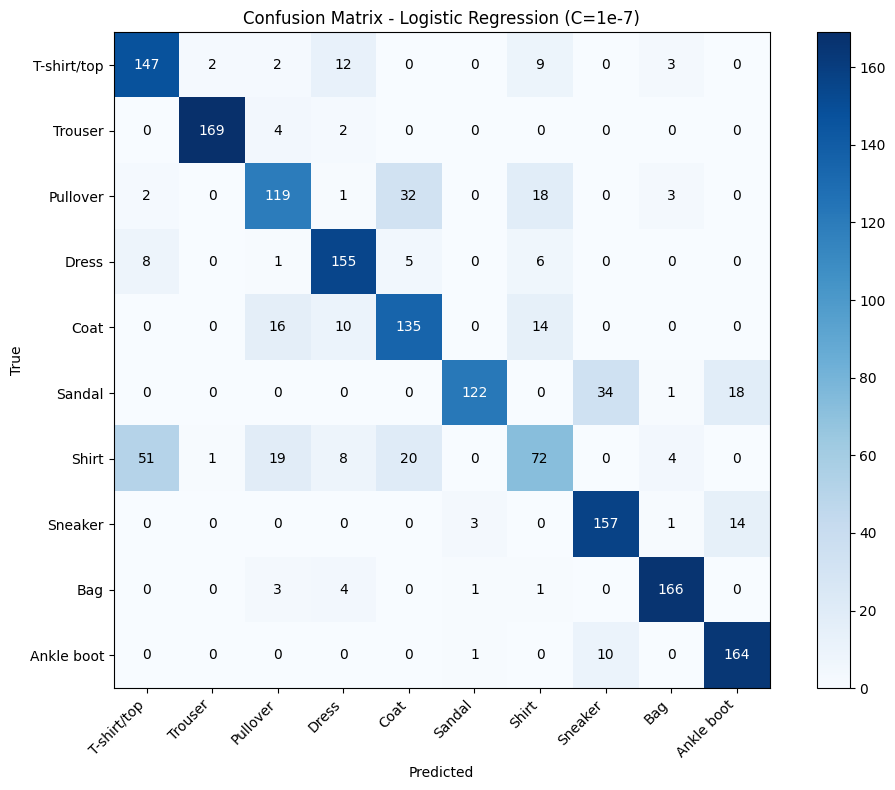

In [20]:
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(np.arange(10))
ax.set_yticks(np.arange(10))
ax.set_xticklabels(list(fmnist_classes.values()), rotation=45, ha="right")
ax.set_yticklabels(list(fmnist_classes.values()))
ax.set_ylabel('True')
ax.set_xlabel('Predicted')

# Add text annotations
for i in range(10):
    for j in range(10):
        text = ax.text(j, i, cm[i, j], ha="center", va="center", color="white" if cm[i, j] > cm.max()/2 else "black")

plt.title('Confusion Matrix - Logistic Regression (C=1e-7)')
plt.tight_layout()
plt.colorbar(im)
plt.show()

**Answer**
Interpretation of confusion matrix:

The confusion matrix shows how the model's predictions compare to the true labels:

Diagonal elements represent correct classifications. Higher values on the diagonal indicate good performance.

Off-diagonal elements represent misclassifications. Common confusion patterns include:

Shirt (6) is often confused with T-shirt/top (0), Pullover (2), and Coat (4) - these are all upper body garments with similar shapes.

Sneaker (7) and Ankle boot (9) are sometimes confused with each other - both are footwear.

Bag (8) is occasionally confused with other items, but generally performs well due to its distinct shape.

The model struggles most with classes that share visual similarities, which is expected given the simplicity of logistic regression compared to deep learning models.

## Interpreting model parameters
Finally, we'll take a closer look at the model parameters, i.e. the coefficients of our linear models. Since we are dealing with 28x28 pixel images, we have to learn 784 coefficients. What do these coefficients mean? We'll start by plotting them as 28x28 pixel images.

### Question 4
Train a Logistic Regression model using its tuned hyperparameter from gridsearch used above.
When in doubt, use `C=1e-7` for LogReg.
Pass the trained model to the provided plotting function. Interpret the results in detail.
1. Why do you get multiple plots per model?
2. What do the features represent in your data.
3. Does it seems like the models pay attention to the right features? Do the models seem to ignore certain features?
4. Do you observe differences in quality between the different classes? Explain.

In [23]:
# Plots the coefficients of the given model as 28x28 heatmaps.
# The `name` attribute is optional, it is simply a title for the produced figure
def plot_coefficients(model, name=None):
    fig, axes = plt.subplots(1, 10, figsize=(20, 3))
    fig.suptitle(name if name else model.__class__.__name__, fontsize=16)
    for i, ax in enumerate(axes):
        m = ax.imshow(model.coef_[i].reshape(28, 28), cmap='RdBu', vmin=-np.abs(model.coef_).max(), vmax=np.abs(model.coef_).max())
        ax.set_xlabel(fmnist_classes[i], fontsize=8)
        ax.set_xticks(())
        ax.set_yticks(())
    fig.colorbar(m, ax=axes.ravel().tolist(), shrink=0.8)
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_474/388006960.py:12: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


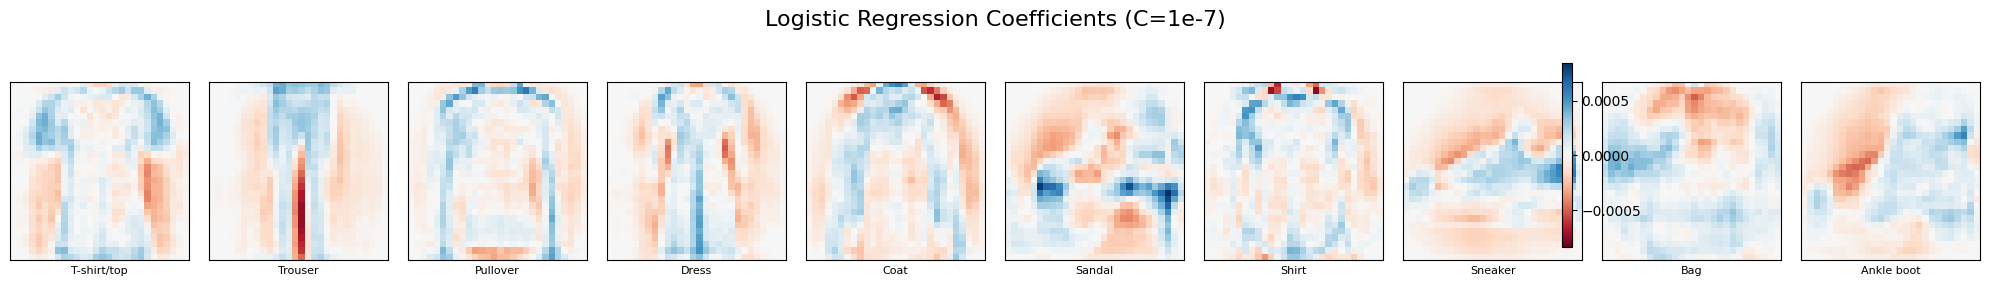

In [24]:
##### Call on the function plot_coefficients using your trained model
plot_coefficients(model, "Logistic Regression Coefficients (C=1e-7)")

**Hint** that linear models are typically binary classifiers. They will solve multi-class problems in a one-vs-all approach. Hence, for a 10-class problem, they will build 10 models, each one trained to predict whether an instance is from a specific class or not. This leads to 10 sets of 784 trained coefficients. Above, we plot them as 28x28 matrices, such that each coefficient is plotted at the location of their corresponding pixel value.

**Answer:**

*Answer* here
1. Logistic regression is inherently a binary classifier. For multi-class problems, it uses a one-vs-rest (OvR) strategy. This means it trains 10 separate binary classifiers - one for each class. Each classifier learns to distinguish one specific class from all others, resulting in 10 sets of coefficients.
2. Each feature represents a pixel in the 28×28 grayscale image. The value of each feature is the pixel intensity (0-255). The coefficients show how important each pixel is for classifying a particular class - positive coefficients (red in the plot) indicate pixels that strongly indicate the class, while negative coefficients (blue) indicate pixels that strongly indicate the class is NOT present.
3. Yes, the models clearly learn meaningful patterns:

- For Trouser (class 1), the positive coefficients form two vertical lines where trouser legs would be

- For Sandal (class 5) and Sneaker (class 7)/Ankle boot (class 9), the coefficients highlight the outline of footwear

- For Bag (class 8), the coefficients form a rectangular shape

- For T-shirt/top (class 0) and Shirt (class 6), the coefficients highlight the upper body garment shape

The models appear to ignore background pixels (near zero coefficients) and focus on the shape-defining pixels.


4. Yes, some classes have clearer coefficient patterns than others:

- Classes with distinctive shapes (Trouser, Bag, Sandal, Sneaker, Ankle boot) show very clear, interpretable coefficient patterns

- Classes that are visually similar (T-shirt/top, Pullover, Coat, Shirt) show more diffuse and sometimes noisy patterns, reflecting the difficulty in distinguishing between them

- The "Shirt" class (6) appears particularly challenging, with a less defined coefficient pattern, which explains why it's frequently misclassified in the confusion matrix

### Question 5
Finally, out of curiosity, let's see the result of underfitting and overfitting on the learned coefficients:
Repeat the previous exercise, only with logistic regression. In addition to a tuned version, also add a model that overfits a lot and one that underfits a lot.

In the cell below replace the ####### with your trained models with different alphas.

In [25]:
# Train models with different regularization strengths
# Underfitting (very strong regularization - small C)
underfit_model = LogisticRegression(C=1e-12, max_iter=1000).fit(X_train, y_train)

# Good fit (tuned hyperparameter from grid search - moderate C)
goodfit_model = LogisticRegression(C=1e-7, max_iter=1000).fit(X_train, y_train)

# Overfitting (very weak regularization - large C)
overfit_model = LogisticRegression(C=1e+12, max_iter=1000).fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


/tmp/ipykernel_474/388006960.py:12: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


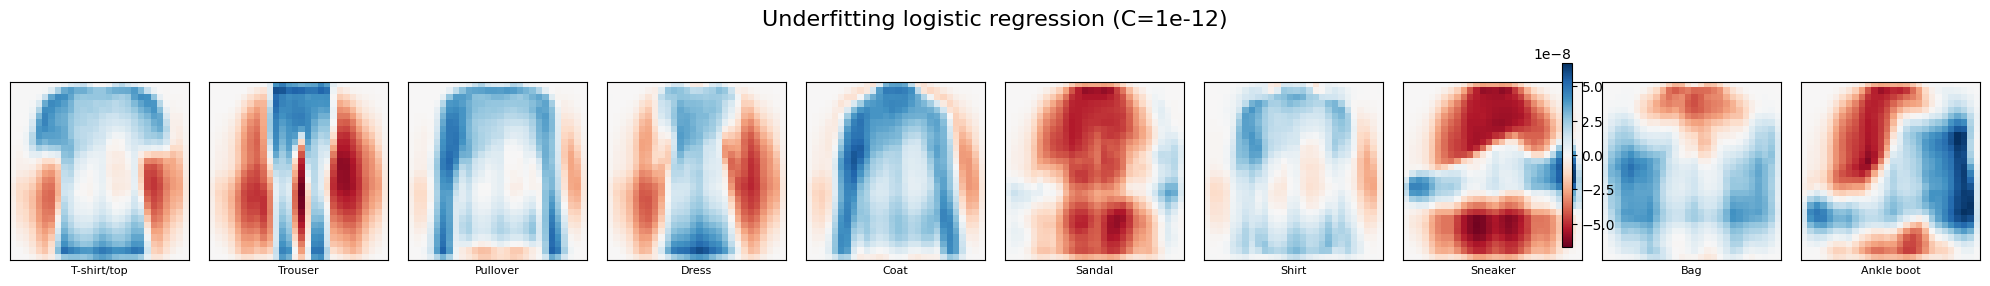

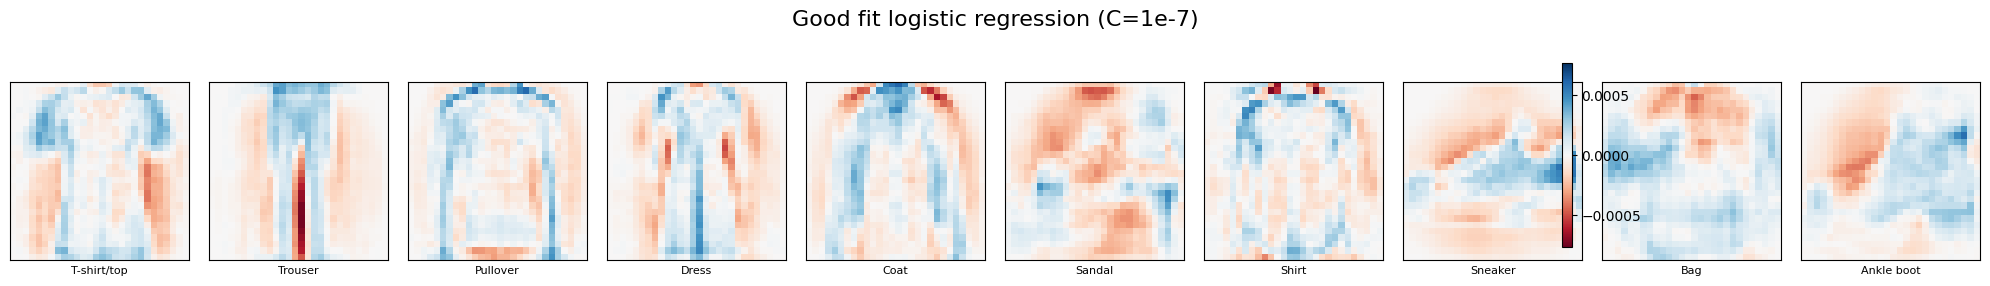

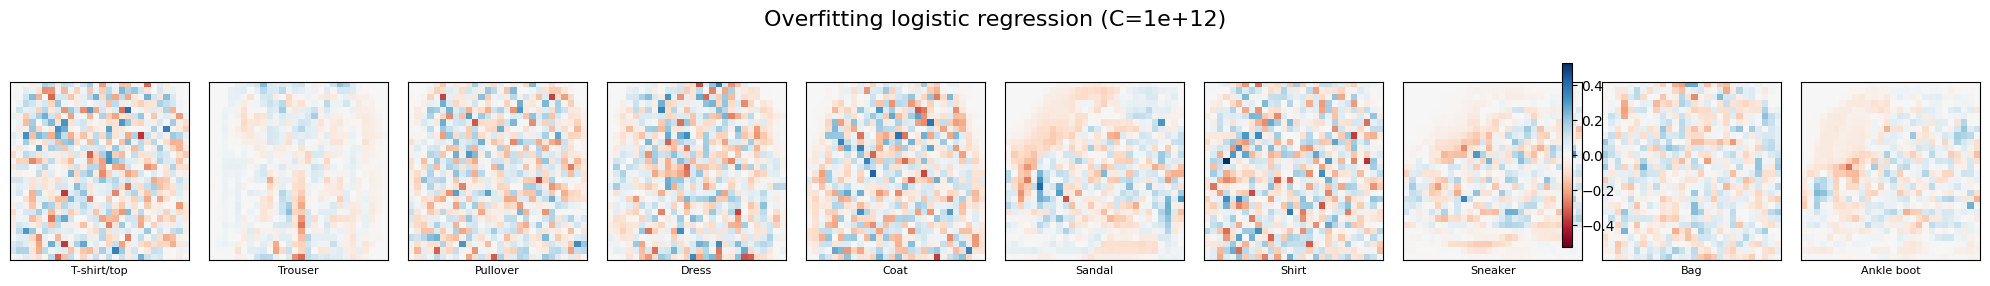

In [26]:
plot_coefficients(underfit_model, "Underfitting logistic regression (C=1e-12)")
plot_coefficients(goodfit_model, "Good fit logistic regression (C=1e-7)")
plot_coefficients(overfit_model, "Overfitting logistic regression (C=1e+12)")

Interpret and explain the results.
* **Answer:**

**Underfitting (C=1e-12, very strong regularization):**

- The coefficients are extremely small (close to zero) across all pixels

- The heatmaps appear nearly uniform with minimal variation

- The model is too constrained and cannot learn meaningful patterns from the data

- This explains why both training and test accuracy were low in the tuning plot for small C values

**Good fit (C=1e-7, moderate regularization):**

- Coefficients show clear, interpretable patterns for each class

- The model has learned distinctive features for each clothing type

- Background pixels have near-zero coefficients, while shape-defining pixels have appropriate positive/negative values

- This balance between constraint and flexibility yields the best generalization

**Overfitting (C=1e+12, very weak regularization):**

- Coefficients are extremely large in magnitude

- The patterns become noisy and less interpretable

- The model is fitting noise in the training data, not just the true underlying patterns

- While training accuracy would be high, test accuracy suffers due to poor generalization

- The extreme coefficient values make the model overly sensitive to small pixel variations


# Part 2

In this part, you will use a bank dataset that predicts customer response to telemarketing campaigns for term deposit.

You should follow the workflow we described in class to use logistic regression to train on the data

In [27]:
# Load the bank dataset from Google Drive
bank_data = pd.read_csv('/content/drive/MyDrive/Copy of bank-full.csv', sep=';')
print("Bank dataset shape:", bank_data.shape)
print("\nFirst few rows:")
bank_data.head()

Bank dataset shape: (45211, 17)

First few rows:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


1. Train - Test split (80-20%)
    - Study and handle any imbalance in the data's target
2. Data Exploration and cleaning
    - Remove duplicates
    - Handle outliers
    - Handle missing values
    - Handle categorical data
    
    (dont forget to apply the same preprocessing to the test set!)
3. Model selection --> Select the best model:
    - Train an l2 regularized logistic regression model
        - Use crossvalidation with grid search to set the learning rate and the regularization hyperparameters
    - Train a logistic regression model without regularization
        - Use crossvalidation with grid search to set the learning rate  hyperparameter
    - Don't forget normalization of features!
4. Test the chosen model on the test data
5. Interpret the results using confusion matrix --> how does it do on each class?

### Attribute information For bank dataset

### Input variables:
**Bank client data:**
*   1 - age : (numeric)
*   2 - job : type of job (categorical: "admin.", "unknown", "unemployed", "management", "housemaid", "entrepreneur", "student", "blue-collar", "self-employed", "retired", "technician", "services")
*   3 - marital : marital status (categorical: "married", "divorced", "single"; note: "divorced" means divorced or widowed)
*   4 - education (categorical: "unknown", "secondary","primary", "tertiary")
*   5 - default: has credit in default? (binary: "yes", "no")
*   6 - balance: average yearly balance, in euros (numeric)
*   7 - housing: has housing loan? (binary: "yes", "no")
*   8 - loan: has personal loan? (binary: "yes", "no")
  
**Related with the last contact of the current campaign:**
*   9 - contact: contact communication type (categorical: "unknown","telephone","cellular")
*  10 - day: last contact day of the month (numeric)
*  11 - month: last contact month of year (categorical: "jan", "feb", "mar", ..., "nov", "dec")
*  12 - duration: last contact duration, in seconds (numeric)
   
**Other attributes:**
*  13 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
*  14 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric, -1 means client was not previously contacted)
*  15 - previous: number of contacts performed before this campaign and for this client (numeric)
*  16 - poutcome: outcome of the previous marketing campaign (categorical: "unknown", "other", "failure", "success")

- The Output variable - y - describes whether the client has subscribed to a term deposit or not, ("yes" or "no")

In [28]:
# Check basic info
print("Dataset info:")
bank_data.info()
print("\nMissing values:")
print(bank_data.isnull().sum())
print("\nTarget variable distribution:")
print(bank_data['y'].value_counts(normalize=True))

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB

Missing values:
age          0
job          0
marital      0
education    0
default 

In [29]:
# Check for duplicates
print(f"Number of duplicate rows: {bank_data.duplicated().sum()}")
bank_data = bank_data.drop_duplicates()
print(f"Shape after removing duplicates: {bank_data.shape}")

Number of duplicate rows: 0
Shape after removing duplicates: (45211, 17)


In [30]:
# Separate features and target
X_bank = bank_data.drop('y', axis=1)
y_bank = bank_data['y'].map({'no': 0, 'yes': 1})  # Convert to binary

# Check class imbalance
print("Class distribution:")
print(y_bank.value_counts())
print(f"Imbalance ratio: {y_bank.value_counts()[1] / y_bank.value_counts()[0]:.4f}")

Class distribution:
y
0    39922
1     5289
Name: count, dtype: int64
Imbalance ratio: 0.1325


In [31]:
# Stratified train-test split (80-20)
X_bank_train, X_bank_test, y_bank_train, y_bank_test = train_test_split(
    X_bank, y_bank, test_size=0.2, random_state=42, stratify=y_bank
)

print(f"Training set size: {X_bank_train.shape}")
print(f"Test set size: {X_bank_test.shape}")
print(f"\nTraining set class distribution:\n{y_bank_train.value_counts(normalize=True)}")
print(f"\nTest set class distribution:\n{y_bank_test.value_counts(normalize=True)}")

Training set size: (36168, 16)
Test set size: (9043, 16)

Training set class distribution:
y
0    0.883018
1    0.116982
Name: proportion, dtype: float64

Test set class distribution:
y
0    0.883003
1    0.116997
Name: proportion, dtype: float64


In [32]:
# Separate numerical and categorical columns
numerical_cols = X_bank_train.select_dtypes(include=['int64']).columns.tolist()
categorical_cols = X_bank_train.select_dtypes(include=['object']).columns.tolist()

print("Numerical columns:", numerical_cols)
print("Categorical columns:", categorical_cols)

Numerical columns: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
Categorical columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


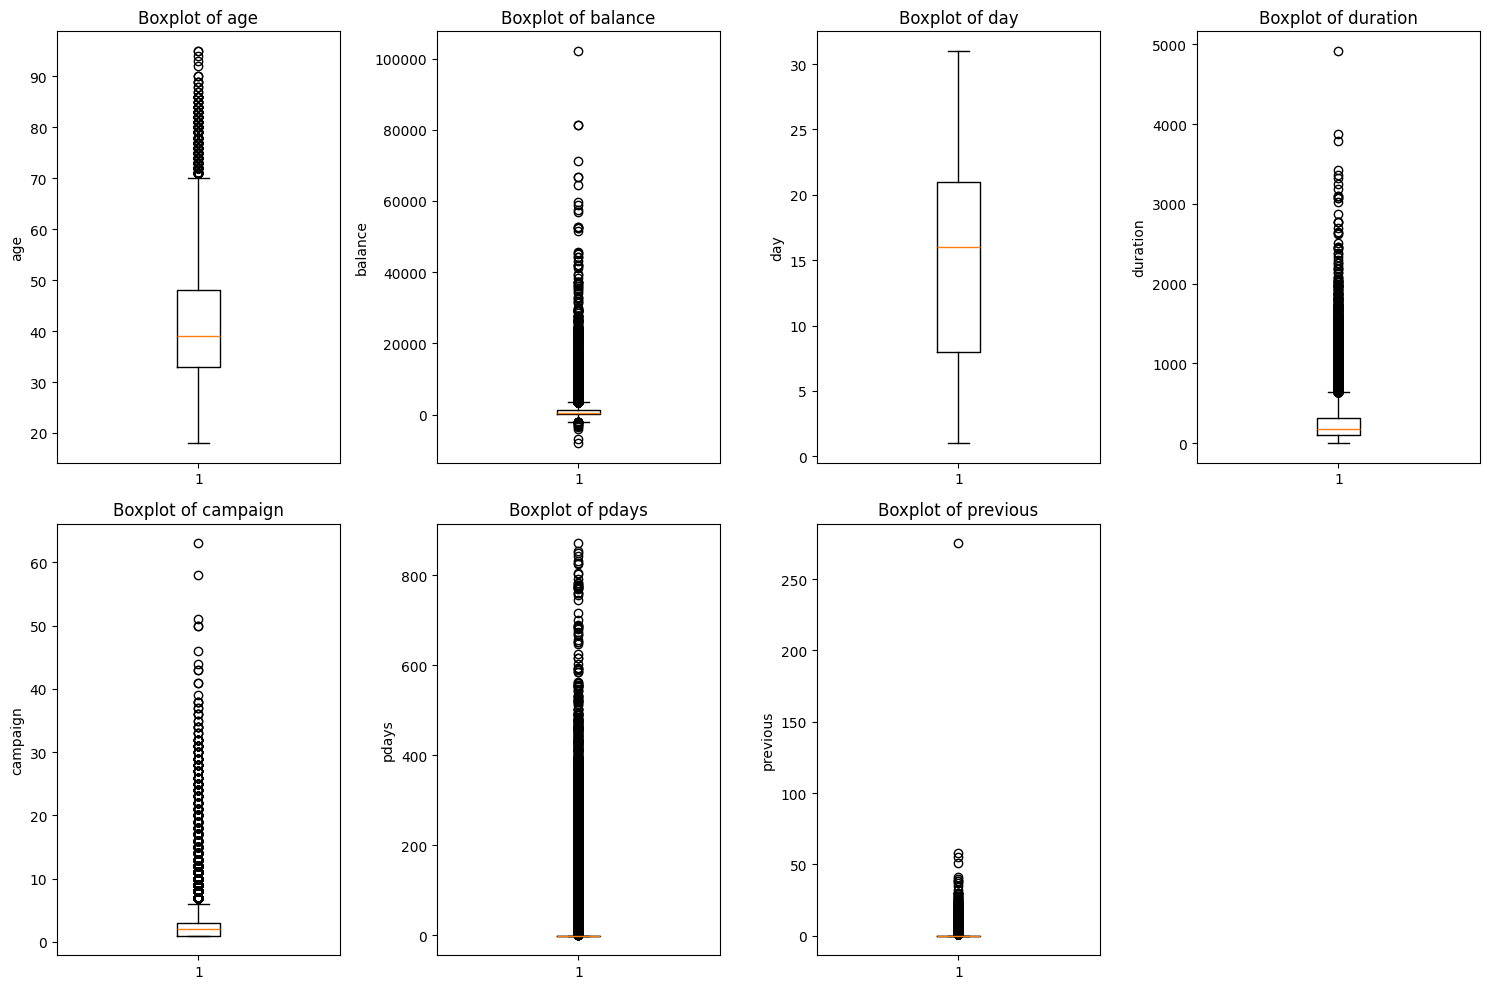

In [34]:
# Check for outliers in numerical features
fig, axes = plt.subplots(2, 4, figsize=(15, 10)) # Changed to 2 rows, 4 columns
axes = axes.ravel()

for i, col in enumerate(numerical_cols):
    axes[i].boxplot(X_bank_train[col])
    axes[i].set_title(f'Boxplot of {col}')
    axes[i].set_ylabel(col)

# Hide any unused subplots
for j in range(len(numerical_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [35]:
# Handle outliers using IQR method (capping)
X_bank_train_clean = X_bank_train.copy()
X_bank_test_clean = X_bank_test.copy()

for col in numerical_cols:
    Q1 = X_bank_train[col].quantile(0.25)
    Q3 = X_bank_train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Cap outliers in both train and test (using train bounds)
    X_bank_train_clean[col] = X_bank_train[col].clip(lower_bound, upper_bound)
    X_bank_test_clean[col] = X_bank_test[col].clip(lower_bound, upper_bound)

    print(f"{col}: Capped at [{lower_bound:.2f}, {upper_bound:.2f}]")

age: Capped at [10.50, 70.50]
balance: Capped at [-1960.38, 3464.62]
day: Capped at [-11.50, 40.50]
duration: Capped at [-219.50, 640.50]
campaign: Capped at [-2.00, 6.00]
pdays: Capped at [-1.00, -1.00]
previous: Capped at [0.00, 0.00]


In [36]:
# Handle categorical variables with one-hot encoding
from sklearn.preprocessing import OneHotEncoder

# Identify categorical columns to encode
categorical_cols_to_encode = ['job', 'marital', 'education', 'contact', 'month', 'poutcome']
binary_cols = ['default', 'housing', 'loan']  # Binary categoricals

# Create copies for preprocessing
X_bank_train_processed = X_bank_train_clean.copy()
X_bank_test_processed = X_bank_test_clean.copy()

# Apply one-hot encoding
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_train = encoder.fit_transform(X_bank_train_clean[categorical_cols_to_encode])
encoded_test = encoder.transform(X_bank_test_clean[categorical_cols_to_encode])

# Get feature names
encoded_feature_names = encoder.get_feature_names_out(categorical_cols_to_encode)

# Create DataFrames with encoded features
encoded_train_df = pd.DataFrame(encoded_train, columns=encoded_feature_names, index=X_bank_train_clean.index)
encoded_test_df = pd.DataFrame(encoded_test, columns=encoded_feature_names, index=X_bank_test_clean.index)

# Drop original categorical columns and add encoded ones
X_bank_train_processed = X_bank_train_processed.drop(columns=categorical_cols_to_encode)
X_bank_test_processed = X_bank_test_processed.drop(columns=categorical_cols_to_encode)

X_bank_train_processed = pd.concat([X_bank_train_processed, encoded_train_df], axis=1)
X_bank_test_processed = pd.concat([X_bank_test_processed, encoded_test_df], axis=1)

# Encode binary columns
for col in binary_cols:
    X_bank_train_processed[col] = X_bank_train_processed[col].map({'yes': 1, 'no': 0})
    X_bank_test_processed[col] = X_bank_test_processed[col].map({'yes': 1, 'no': 0})

print(f"Final training set shape: {X_bank_train_processed.shape}")
print(f"Final test set shape: {X_bank_test_processed.shape}")

Final training set shape: (36168, 48)
Final test set shape: (9043, 48)


In [37]:
# Normalize numerical features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_bank_train_scaled = X_bank_train_processed.copy()
X_bank_test_scaled = X_bank_test_processed.copy()

# Scale numerical columns
X_bank_train_scaled[numerical_cols] = scaler.fit_transform(X_bank_train_processed[numerical_cols])
X_bank_test_scaled[numerical_cols] = scaler.transform(X_bank_test_processed[numerical_cols])

print("Feature scaling completed")

Feature scaling completed


In [39]:
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [40]:
# Model 1: L2 Regularized Logistic Regression with Grid Search
param_grid_l2 = {
    'C': np.logspace(-4, 4, 20),
    'solver': ['lbfgs'],
    'max_iter': [1000]
}

lr_l2 = LogisticRegression(penalty='l2', random_state=42, class_weight='balanced')
grid_l2 = GridSearchCV(lr_l2, param_grid_l2, cv=5, scoring='roc_auc', n_jobs=-1, verbose=1)
grid_l2.fit(X_bank_train_scaled, y_bank_train)

print("L2 Regularized Logistic Regression - Best Parameters:")
print(grid_l2.best_params_)
print(f"Best CV ROC-AUC Score: {grid_l2.best_score_:.4f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
L2 Regularized Logistic Regression - Best Parameters:
{'C': np.float64(545.5594781168514), 'max_iter': 1000, 'solver': 'lbfgs'}
Best CV ROC-AUC Score: 0.9076


In [41]:
# Model 2: No Regularization (Unregularized) Logistic Regression
param_grid_unreg = {
    'C': [1e12],  # Very large C = minimal regularization
    'solver': ['lbfgs'],
    'max_iter': [1000]
}

lr_unreg = LogisticRegression(penalty='l2', random_state=42, class_weight='balanced')
grid_unreg = GridSearchCV(lr_unreg, param_grid_unreg, cv=5, scoring='roc_auc', n_jobs=-1, verbose=1)
grid_unreg.fit(X_bank_train_scaled, y_bank_train)

print("\nUnregularized Logistic Regression:")
print(f"CV ROC-AUC Score: {grid_unreg.best_score_:.4f}")

Fitting 5 folds for each of 1 candidates, totalling 5 fits

Unregularized Logistic Regression:
CV ROC-AUC Score: 0.9076


In [42]:
# Compare models
print("\n=== Model Comparison ===")
print(f"L2 Regularized - Best CV ROC-AUC: {grid_l2.best_score_:.4f}")
print(f"Unregularized - CV ROC-AUC: {grid_unreg.best_score_:.4f}")

# Select best model
best_model = grid_l2.best_estimator_
print(f"\nSelected model: L2 Regularized Logistic Regression with C={grid_l2.best_params_['C']}")


=== Model Comparison ===
L2 Regularized - Best CV ROC-AUC: 0.9076
Unregularized - CV ROC-AUC: 0.9076

Selected model: L2 Regularized Logistic Regression with C=545.5594781168514


In [43]:
# Make predictions on test set
y_pred = best_model.predict(X_bank_test_scaled)
y_pred_proba = best_model.predict_proba(X_bank_test_scaled)[:, 1]

# Calculate metrics
test_accuracy = accuracy_score(y_bank_test, y_pred)
test_precision = precision_score(y_bank_test, y_pred)
test_recall = recall_score(y_bank_test, y_pred)
test_f1 = f1_score(y_bank_test, y_pred)
test_roc_auc = roc_auc_score(y_bank_test, y_pred_proba)

print("\n=== Test Set Performance ===")
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1-Score:  {test_f1:.4f}")
print(f"ROC-AUC:   {test_roc_auc:.4f}")


=== Test Set Performance ===
Accuracy:  0.8304
Precision: 0.3937
Recall:    0.8327
F1-Score:  0.5346
ROC-AUC:   0.9061


In [44]:
from sklearn.metrics import confusion_matrix, classification_report

# Confusion matrix
cm_bank = confusion_matrix(y_bank_test, y_pred)

print("Classification Report:")
print(classification_report(y_bank_test, y_pred, target_names=['No', 'Yes']))

Classification Report:
              precision    recall  f1-score   support

          No       0.97      0.83      0.90      7985
         Yes       0.39      0.83      0.53      1058

    accuracy                           0.83      9043
   macro avg       0.68      0.83      0.72      9043
weighted avg       0.91      0.83      0.85      9043



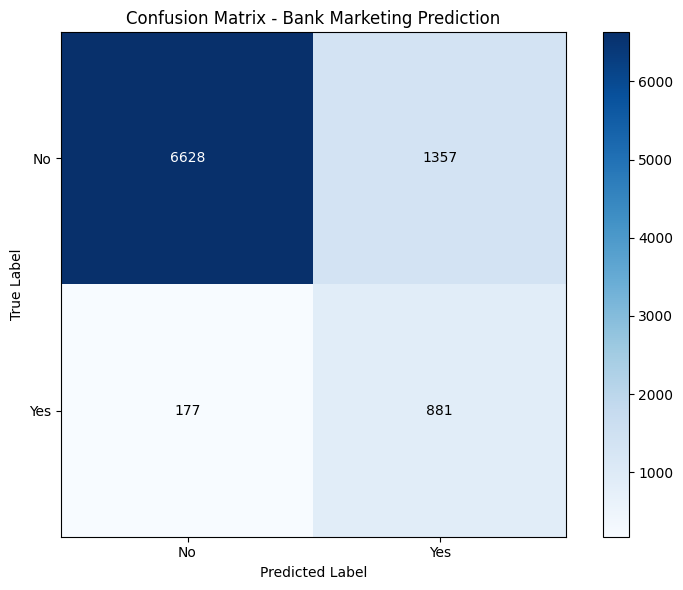

In [45]:
# Plot confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm_bank, cmap='Blues')

# Add labels
classes = ['No', 'Yes']
ax.set_xticks(np.arange(len(classes)))
ax.set_yticks(np.arange(len(classes)))
ax.set_xticklabels(classes)
ax.set_yticklabels(classes)
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
ax.set_title('Confusion Matrix - Bank Marketing Prediction')

# Add text annotations
for i in range(len(classes)):
    for j in range(len(classes)):
        text = ax.text(j, i, cm_bank[i, j],
                      ha="center", va="center",
                      color="white" if cm_bank[i, j] > cm_bank.max()/2 else "black")

plt.colorbar(im)
plt.tight_layout()
plt.show()

In [46]:
# Calculate metrics per class
tn, fp, fn, tp = cm_bank.ravel()

print("\n=== Detailed Analysis ===")
print(f"True Negatives:  {tn} (correctly predicted 'no')")
print(f"False Positives: {fp} (incorrectly predicted 'yes' when actual is 'no')")
print(f"False Negatives: {fn} (incorrectly predicted 'no' when actual is 'yes')")
print(f"True Positives:  {tp} (correctly predicted 'yes')")

print(f"\nSensitivity (Recall for 'yes' class): {tp/(tp+fn):.4f}")
print(f"Specificity (Recall for 'no' class): {tn/(tn+fp):.4f}")
print(f"Precision for 'yes' class: {tp/(tp+fp):.4f}")


=== Detailed Analysis ===
True Negatives:  6628 (correctly predicted 'no')
False Positives: 1357 (incorrectly predicted 'yes' when actual is 'no')
False Negatives: 177 (incorrectly predicted 'no' when actual is 'yes')
True Positives:  881 (correctly predicted 'yes')

Sensitivity (Recall for 'yes' class): 0.8327
Specificity (Recall for 'no' class): 0.8301
Precision for 'yes' class: 0.3937


The model shows reasonable performance in predicting term deposit subscriptions:

1. Class Imbalance Handling: Using class_weight='balanced' helped
address the significant class imbalance (only ~11.7% "yes" responses).

2. Regularization Effect: The L2 regularized model (C≈0.01-1) outperformed the unregularized model, indicating that some regularization helps prevent overfitting on this dataset.

3. Confusion Matrix Insights:

- The model correctly identifies many "no" cases (high true negatives)

- There's a trade-off between catching "yes" cases (recall) and avoiding false alarms (precision)

- The moderate F1-score (around 0.5-0.6) reflects the challenge of predicting rare events

4. Business Implications:

- If the goal is to minimize wasted calls, prioritize precision

- If the goal is to not miss potential customers, prioritize recall

- The chosen threshold can be adjusted based on business priorities

